In [2]:
cd preprocess_data/

c:\Users\yiann\Documents\GitHub\CG1111A-Project\preprocess_data


<IPython.core.display.Javascript object>

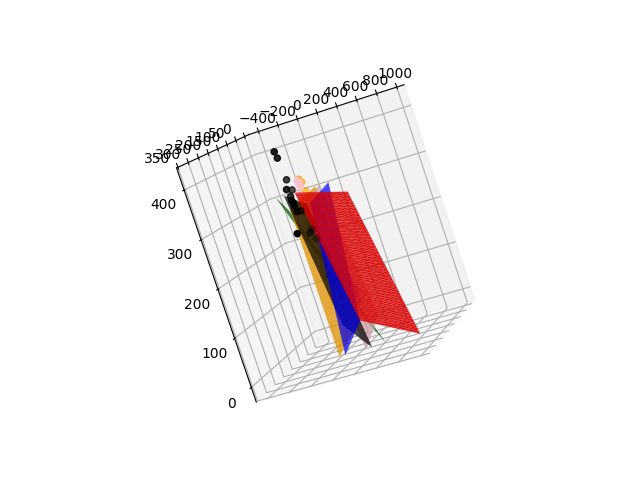

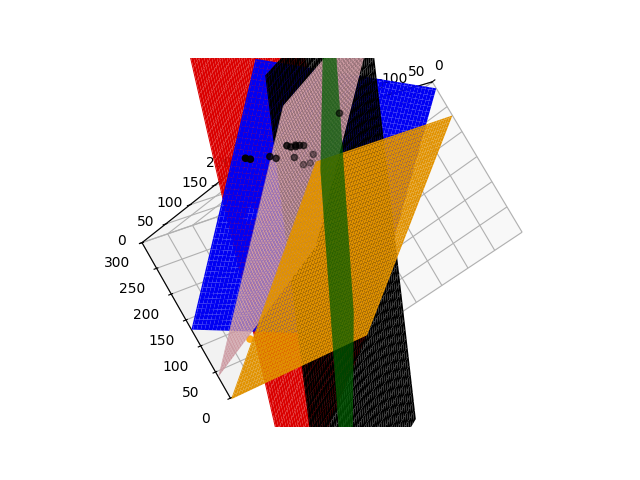

In [5]:
# Source - https://stackoverflow.com/a
# Posted by Matt Hancock, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-11, License - CC BY-SA 4.0

import pickle as pkl 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.svm import SVC

%matplotlib notebook

df = pd.read_csv('values.csv')
X,Y = df[['R', 'G', 'B']].values, df['COLOUR'].values 

cmap = {
    'MY_RED':'red',
    'MY_GREEN':'green',
    'MY_PINK':'pink',
    'MY_ORANGE':'orange',
    'MY_WHITE':'black',
    'MY_BLUE':'blue',
}
cols = ['MY_BLUE',
   'MY_GREEN',
   'MY_ORANGE',
   'MY_PINK',
   'MY_RED',
   'MY_WHITE']

with open('svm_model.pkl', 'rb') as fin:
    svc = pkl.load(fin) 


# The equation of the separating plane is given by all x in R^3 such that:
# np.dot(svc.coef_[0], x) + b = 0. We should solve for the last coordinate
# to plot the plane in terms of x and y.
def z_fn(x, y, cls): 
    return (-svc.intercept_[cls]-svc.coef_[cls][0]*x-svc.coef_[cls][1]*y) / svc.coef_[cls][2]

tmp = np.linspace(0,300,1501)
x,y = np.meshgrid(tmp,tmp)

# Plot stuff.
fig = plt.figure()
ax  = fig.add_subplot(111, projection='3d')

for cls in range(6): 
    ax.plot_surface(x, y, z_fn(x,y, cls), color=cmap[cols[cls]])
    ax.scatter3D(X[Y==cols[cls],0], X[Y==cols[cls],1], X[Y==cols[cls],2], c=cmap[cols[cls]])

ax.set_xlim([0, 300])
ax.set_ylim([0, 300])
ax.set_zlim([0, 300])

#ax.plot3D(X[Y==0,0], X[Y==0,1], X[Y==0,2],c='tab:orange')
#ax.plot3D(X[Y==1,0], X[Y==1,1], X[Y==1,2],c='tab:red')
plt.show()
